# Exercise 2: Attitude Estimation for an Autonomous Underwater Vehicle

This notebook is for the course exercise on **attitude estimation** for an AUV using a 3-axis gyroscope, accelerometer, and magnetometer.

You will implement and compare gyro-only propagation, a complementary filter, and an EKF. The section order is aligned with the reference solution notebook.


## 1. Learning goals

- propagate attitude from gyroscope data
- compute roll and pitch from the accelerometer
- compute yaw from a tilt-compensated magnetometer
- implement a complementary filter
- implement and tune an EKF for attitude estimation
- analyze performance under gyro drift, dynamic acceleration, and magnetic disturbance


## 2. Imports


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## 3. Helper functions


In [ ]:
def wrap_angle(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi

def euler_kinematics_matrix(phi, theta):
    cphi = np.cos(phi)
    sphi = np.sin(phi)
    ctheta = np.cos(theta)
    ctheta = np.where(np.abs(ctheta) < 1e-6, np.sign(ctheta + 1e-15) * 1e-6, ctheta)
    ttheta = np.tan(theta)
    return np.array([
        [1.0, sphi * ttheta, cphi * ttheta],
        [0.0, cphi,         -sphi],
        [0.0, sphi / ctheta, cphi / ctheta]
    ])

def rot_x(phi):
    c = np.cos(phi); s = np.sin(phi)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]])

def rot_y(theta):
    c = np.cos(theta); s = np.sin(theta)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]])

def rot_z(psi):
    c = np.cos(psi); s = np.sin(psi)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])

def R_nb(phi, theta, psi):
    """Body-to-navigation rotation matrix (ZYX convention)."""
    return rot_z(psi) @ rot_y(theta) @ rot_x(phi)

def R_bn(phi, theta, psi):
    """Navigation-to-body rotation matrix."""
    return R_nb(phi, theta, psi).T

def finite_difference_jacobian(f, x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    y0 = np.asarray(f(x))
    J = np.zeros((y0.size, x.size))
    for i in range(x.size):
        dx = np.zeros_like(x)
        dx[i] = eps
        y1 = np.asarray(f(x + dx))
        J[:, i] = (y1 - y0) / eps
    return J


## 4. Synthetic dataset generation

We generate a smooth synthetic AUV attitude trajectory and corresponding gyroscope, accelerometer, and magnetometer measurements.


In [ ]:
rng = np.random.default_rng(7)

dt = 0.05 #20Hz
T  = 180.0
t  = np.arange(0.0, T + dt, dt)
N  = len(t)

g     = 9.81
mag_n = np.array([0.45, 0.0, 0.25], dtype=float)
mag_n = mag_n / np.linalg.norm(mag_n)

# Ground-truth Euler-angle trajectories (smooth sinusoidal motion)
phi_true   = 0.18 * np.sin(0.09 * t) + 0.05 * np.sin(0.31 * t + 0.5)
theta_true = 0.12 * np.sin(0.07 * t + 0.8) + 0.03 * np.sin(0.23 * t)
psi_true   = wrap_angle(0.015 * t + 0.35 * np.sin(0.045 * t) + 0.08 * np.sin(0.12 * t + 0.2))
att_true   = np.column_stack([phi_true, theta_true, psi_true])

# Euler-angle rates via numerical differentiation.
# NOTE: for yaw we must unwrap first to avoid spurious jumps at +-pi
# before differentiating, then re-wrap the result.
att_dot       = np.gradient(att_true, dt, axis=0)
att_dot[:, 2] = np.gradient(np.unwrap(psi_true), dt)

# inverse of the Euler kinematics matrix W.
# Hint: for each time step k,
#   W = euler_kinematics_matrix(phi_true[k], theta_true[k])
#   gyro_true[k] = np.linalg.solve(W, att_dot[k])
gyro_true = np.zeros((N, 3))
for k in range(N):
    W = euler_kinematics_matrix(phi_true[k], theta_true[k])
    gyro_true[k] = np.linalg.solve(W, att_dot[k])

gyro_bias      = np.array([0.004, -0.003, 0.005])
gyro_noise_std = np.array([0.003, 0.003, 0.004])
gyro = gyro_true + gyro_bias + rng.normal(0.0, gyro_noise_std, size=(N, 3))

acc = np.zeros((N, 3))
mag = np.zeros((N, 3))

# Disturbance windows (keep these fixed so your results match the reference)
# These define time windows where sensors are corrupted
acc_disturbance_mask = ((t >= 55.0) & (t <= 72.0)) | ((t >= 125.0) & (t <= 138.0))
mag_disturbance_mask = (t >= 95.0) & (t <= 112.0)

for k in range(N):
    phi, theta, psi = att_true[k]
    R = R_bn(phi, theta, psi)
    g_n = np.array([0.0, 0.0, g])
    acc_nominal = R @ g_n
    dyn = np.zeros(3)
    if acc_disturbance_mask[k]:
        dyn = np.array([
            1.2 * np.sin(0.8 * t[k]),
            0.8 * np.cos(1.1 * t[k]),
            0.5 * np.sin(0.6 * t[k] + 0.2),
        ])
    acc[k] = acc_nominal + dyn + rng.normal(0.0, [0.08, 0.08, 0.10])

    mag_nominal = R @ mag_n
    mag_dist = np.zeros(3)
    if mag_disturbance_mask[k]:
        mag_dist = np.array([0.35, -0.20, 0.10])
    mag[k] = mag_nominal + mag_dist + rng.normal(0.0, [0.015, 0.015, 0.015])


## 5. Inspect the synthetic sensor data


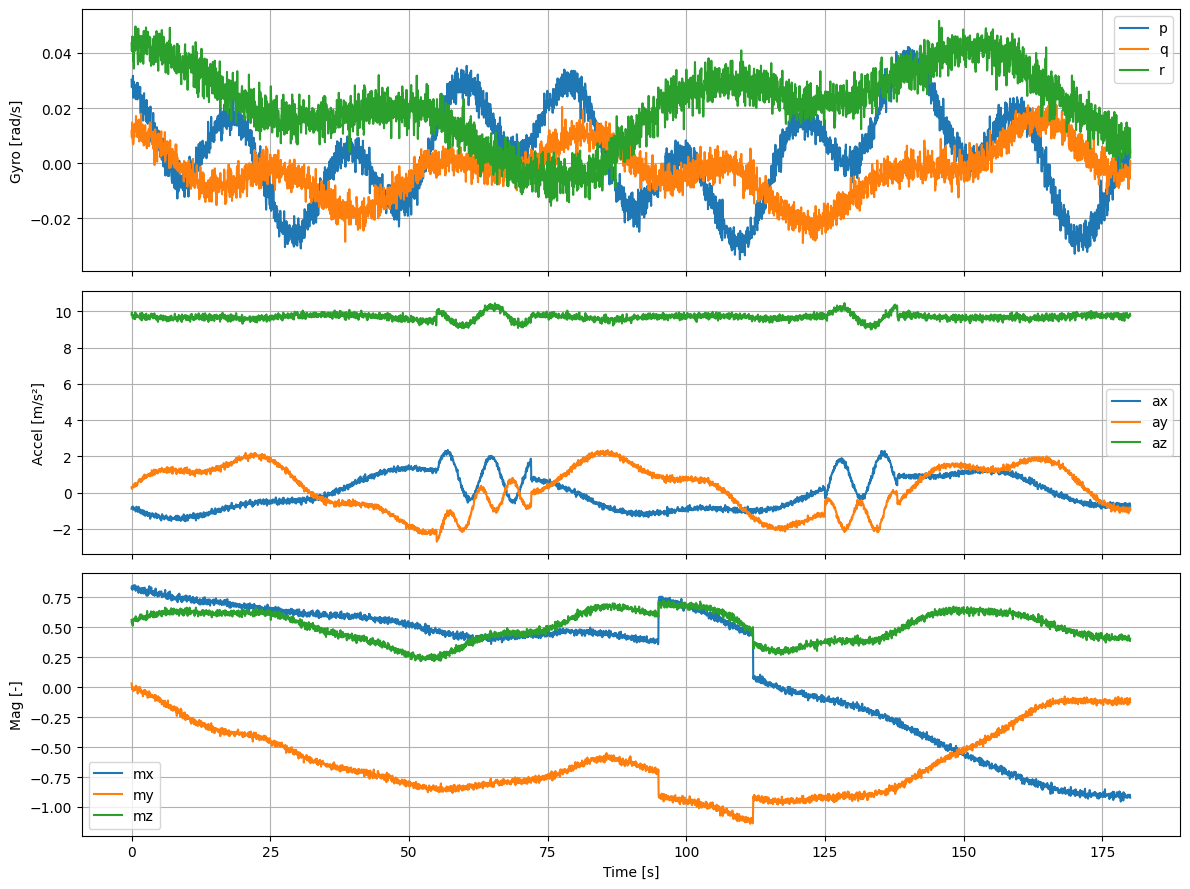

In [ ]:
# TODO: plot gyroscope, accelerometer, and magnetometer measurements versus time.

fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# axs[0]: gyro channels p, q, r  (label axes correctly)
# axs[1]: accel channels ax, ay, az
# axs[2]: magnetometer channels mx, my, mz

axs[0].plot(t, gyro[:, 0], label="p")
axs[0].plot(t, gyro[:, 1], label="q")
axs[0].plot(t, gyro[:, 2], label="r")
axs[0].set_ylabel("Gyro [rad/s]")
axs[0].legend()

axs[1].plot(t, acc[:, 0], label="ax")
axs[1].plot(t, acc[:, 1], label="ay")
axs[1].plot(t, acc[:, 2], label="az")
axs[1].set_ylabel("Accel [m/s²]")
axs[1].legend()

axs[2].plot(t, mag[:, 0], label="mx")
axs[2].plot(t, mag[:, 1], label="my")
axs[2].plot(t, mag[:, 2], label="mz")
axs[2].set_ylabel("Mag [-]")
axs[2].set_xlabel("Time [s]")
axs[2].legend()

plt.tight_layout()
plt.show()


## 6. Attitude pseudo-measurements from accelerometer and magnetometer


In [ ]:
# TODO: implement the conversion from accelerometer to roll and pitch.
# Formulas (small-angle, NED convention, body frame):
#   phi   = arctan2(ay, az)
#   theta = arctan2(-ax, sqrt(ay^2 + az^2))

def accel_to_roll_pitch(acc_sample):
    ax, ay, az = acc_sample
    phi_acc = np.arctan2(ay, az)
    theta_acc = np.arctan2(-ax, np.sqrt(ay**2 + az**2))
    return wrap_angle(phi_acc), wrap_angle(theta_acc)


# TODO: implement tilt-compensated yaw from magnetometer.
# Tilt-compensate by projecting the magnetometer into the horizontal plane:
#   mx_h = mx*cos(theta) + my*sin(phi)*sin(theta) + mz*cos(phi)*sin(theta)
#   my_h = my*cos(phi) - mz*sin(phi)
#   psi  = arctan2(-my_h, mx_h)

def mag_to_yaw(mag_sample, phi, theta):
    mx, my, mz = mag_sample
    mx_h = mx * np.cos(theta) + my * np.sin(phi) * np.sin(theta) + mz * np.cos(phi) * np.sin(theta)
    my_h = my * np.cos(phi) - mz * np.sin(phi)
    psi_mag = np.arctan2(-my_h, mx_h)
    return wrap_angle(psi_mag)


att_meas = np.zeros((N, 3))
for k in range(N):
    phi_acc, theta_acc = accel_to_roll_pitch(acc[k])
    psi_mag            = mag_to_yaw(mag[k], phi_acc, theta_acc)
    att_meas[k]        = np.array([phi_acc, theta_acc, psi_mag])


## 7. Compare pseudo-measurements to ground truth


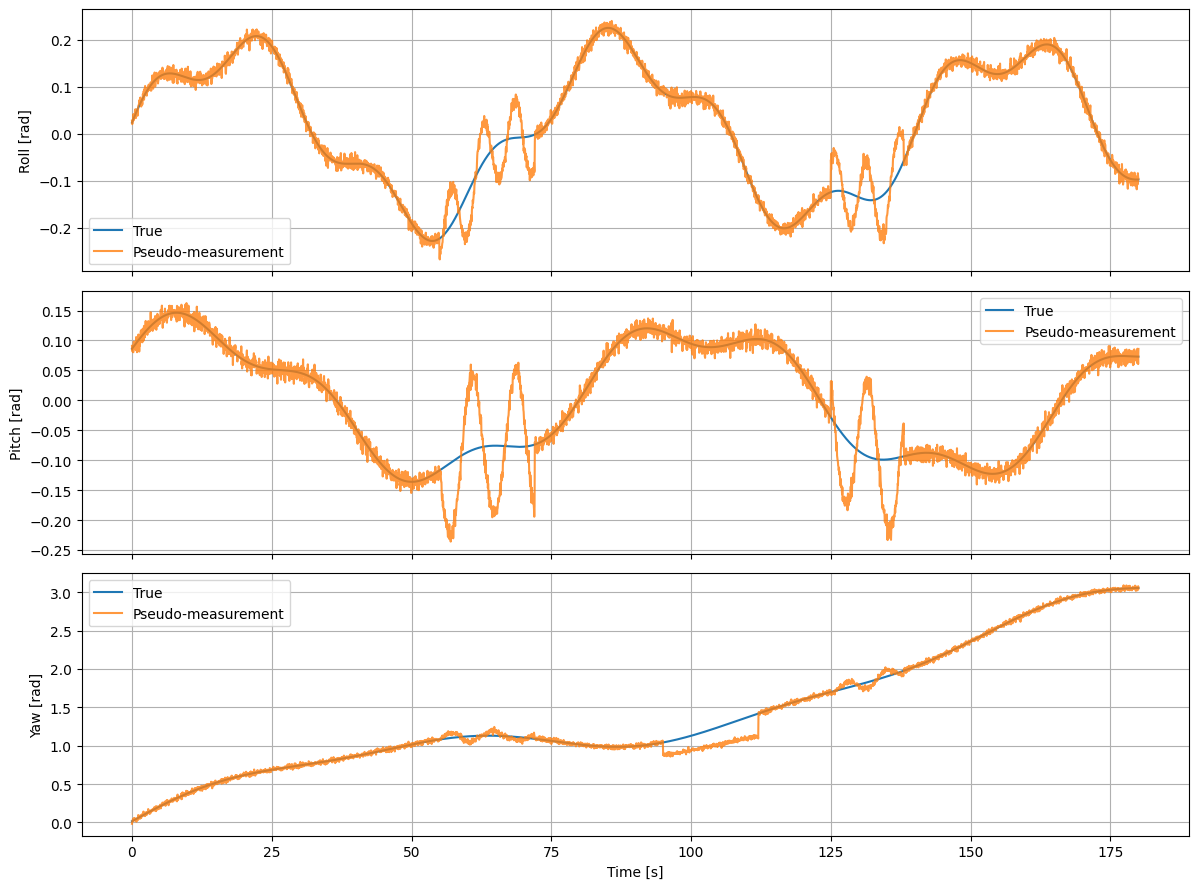

In [ ]:
# TODO: plot true roll/pitch/yaw against the pseudo-measurements.

labels = ["Roll [rad]", "Pitch [rad]", "Yaw [rad]"]
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# For each angle, plot att_true[:,i] and att_meas[:,i]
for i in range(3):
    axs[i].plot(t, att_true[:, i], label="True")
    axs[i].plot(t, att_meas[:, i], label="Pseudo-measurement", alpha=0.8)
    axs[i].set_ylabel(labels[i])
    axs[i].legend()

axs[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()


## 8. Gyroscope-only attitude propagation


In [ ]:
att_gyro    = np.zeros((N, 3))
att_gyro[0] = att_meas[0]  # initialize from first pseudo-measurement

for k in range(N - 1):
    phi, theta, psi = att_gyro[k]
    # TODO Perform discrete integration of gyro measurements:
    W = euler_kinematics_matrix(phi, theta)
    euler_dot = W @ gyro[k]
    att_gyro[k + 1] = att_gyro[k] + dt * euler_dot
    att_gyro[k + 1, 0] = wrap_angle(att_gyro[k + 1, 0])
    att_gyro[k + 1, 1] = wrap_angle(att_gyro[k + 1, 1])
    att_gyro[k + 1, 2] = wrap_angle(att_gyro[k + 1, 2])


## 10. EKF model

We use the EKF state $x=[\phi,\theta,\psi]^T$ with gyro-based prediction and pseudo-measurement update.


In [ ]:
# TODO: implement the EKF process model, prediction step, and update step.


def process_model(x, gyro_sample, dt):
    """Nonlinear state propagation: integrate Euler kinematics one step.

    Returns the predicted state with all angles wrapped to [-pi, pi).
    """
    phi, theta, psi = x
    W = euler_kinematics_matrix(phi, theta)
    x_pred = x + dt * (W @ gyro_sample)
    return np.array([wrap_angle(x_pred[0]), wrap_angle(x_pred[1]), wrap_angle(x_pred[2])])


def ekf_predict(x, P, gyro_sample, dt, Q):
    """EKF prediction step.

    1. Propagate mean:
    2. Linearize:
    3. Propagate covariance:
    """
    x_pred = process_model(x, gyro_sample, dt)

    def f_local(x_local):
        return process_model(x_local, gyro_sample, dt)

    F = finite_difference_jacobian(f_local, x)
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred


def ekf_update(x, P, z, R):
    """EKF update step with pseudo-measurement z = [phi_acc, theta_acc, psi_mag].

    The measurement model is H = I (direct angle observation)

    Use the Joseph stabilized form for the covariance update:

    Return x_upd, P_upd, y
    """
    H = np.eye(3) # jacobian of the measurement model
    y = z - x
    y[0] = wrap_angle(y[0])
    y[1] = wrap_angle(y[1])
    y[2] = wrap_angle(y[2])
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    x_upd = x + K @ y
    x_upd = np.array([wrap_angle(x_upd[0]), wrap_angle(x_upd[1]), wrap_angle(x_upd[2])])
    I = np.eye(3)
    IKH = I - K @ H
    P_upd = IKH @ P @ IKH.T + K @ R @ K.T
    return x_upd, P_upd, y


## 11. Run the EKF


In [ ]:
# Starting tuning values — feel free to experiment
x = att_meas[0].copy()

# TODO Tune P and Q for the ekf
P = np.diag([0.08, 0.08, 0.10])
Q = np.diag([1.5e-4, 1.5e-4, 2.0e-4])
R = np.diag([8e-3, 8e-3, 1.5e-2])

att_ekf    = np.zeros((N, 3))
innov      = np.zeros((N, 3))
att_ekf[0] = x

for k in range(N - 1):
    # TODO:
    x, P       = ekf_predict(x, P, gyro[k], dt, Q)
    x, P, y    = ekf_update(x, P, att_meas[k + 1], R)
    att_ekf[k + 1] = x
    innov[k + 1]   = y
    pass


## 12. Compare gyro-only, and EKF


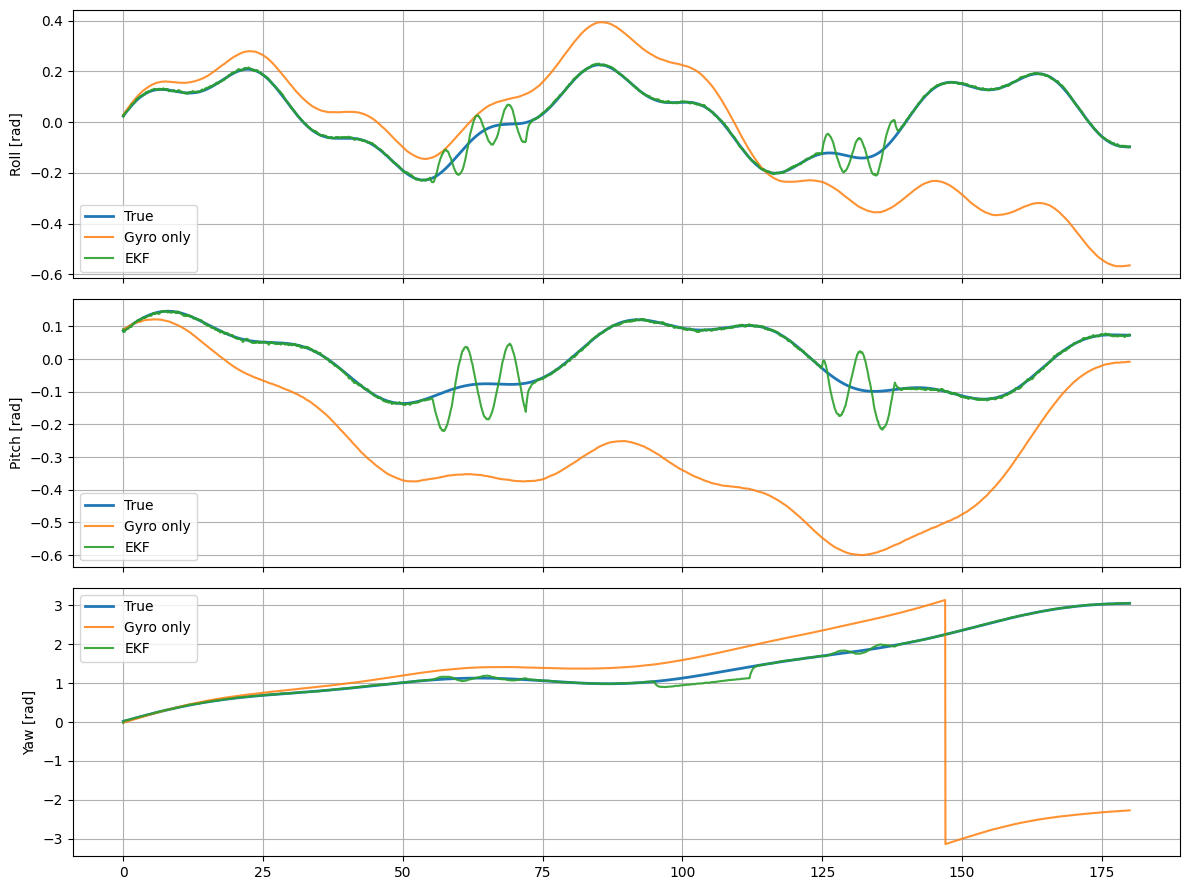

In [ ]:
# TODO: create one subplot for each angle showing true attitude and all three estimates.

labels = ["Roll [rad]", "Pitch [rad]", "Yaw [rad]"]
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# For each angle i plot: att_true[:,i], att_gyro[:,i], att_ekf[:,i]
for i in range(3):
    axs[i].plot(t, att_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, att_gyro[:, i], label="Gyro only", alpha=0.85)
    axs[i].plot(t, att_ekf[:, i], label="EKF", alpha=0.90)
    axs[i].set_ylabel(labels[i])
    axs[i].legend()

plt.tight_layout()
plt.show()


## 13. Error metrics


In [ ]:
# TODO: implement angle_rmse and compute RMSE for each estimator.

def angle_rmse(est, true):
    """Return per-axis RMSE [roll, pitch, yaw] with angle wrapping.

    Hint: wrap_angle works element-wise on arrays, so
      err_wrapped = wrap_angle(est - true)
    is sufficient — no Python loop needed.
    """
    err = est - true
    err_wrapped = wrap_angle(err)
    return np.sqrt(np.mean(err_wrapped**2, axis=0))


rmse_gyro = angle_rmse(att_gyro, att_true)
rmse_ekf  = angle_rmse(att_ekf,  att_true)

print("RMSE gyro-only     [roll, pitch, yaw]:", rmse_gyro)
print("RMSE EKF           [roll, pitch, yaw]:", rmse_ekf)


RMSE gyro-only     [roll, pitch, yaw]: [0.24248685 0.32398448 0.55834206]
RMSE EKF           [roll, pitch, yaw]: [0.02235047 0.03233846 0.06942873]


## 14. Innovation analysis


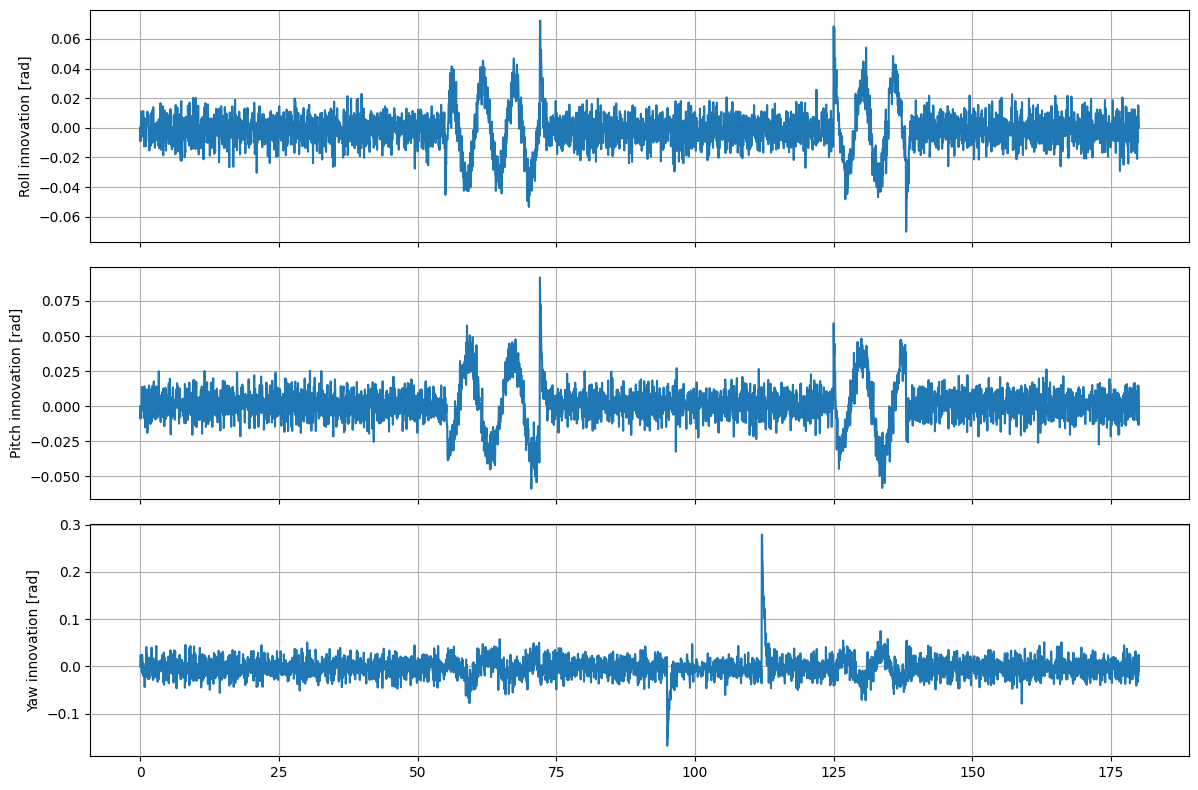

In [ ]:
# TODO: plot EKF innovation signals for roll, pitch, and yaw.

names = ["Roll innovation [rad]", "Pitch innovation [rad]", "Yaw innovation [rad]"]
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# For each axis i: axs[i].plot(t, innov[:, i])
for i in range(3):
    axs[i].plot(t, innov[:, i])
    axs[i].set_ylabel(names[i])

plt.tight_layout()
plt.show()


## 15. Robustness experiments

The dataset contains deliberate disturbance intervals:

- **Accelerometer disturbance**: t ∈ [55, 72] s and [125, 138] s
- **Magnetometer disturbance**: t ∈ [95, 112] s

Use the plots and metrics above to answer the following questions:

1. How does each estimator behave during the accelerometer disturbance windows?
2. How does yaw estimation degrade during the magnetometer disturbance?
3. Why does gyro-only propagation drift even outside disturbance windows?


In [ ]:
# Write your observations and any additional plots here.


## 16. Optional extensions

- add gyro bias to the EKF state
- replace Euler angles with quaternions


In [ ]:
# Optional work area
